### Análisis de datos II
## EDA dataset Pinguinos
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
penguins = sns.load_dataset("penguins").dropna()

### Información general y tipos de datos

In [3]:
penguins.info()

<class 'pandas.core.frame.DataFrame'>
Index: 333 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            333 non-null    object 
 1   island             333 non-null    object 
 2   bill_length_mm     333 non-null    float64
 3   bill_depth_mm      333 non-null    float64
 4   flipper_length_mm  333 non-null    float64
 5   body_mass_g        333 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 20.8+ KB


### Vista general del dataset

In [4]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [5]:
f_numericas = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
f_categoricas = ['species', 'island', 'sex']

---
### Variables categóricas
---

#### Exploración general

In [6]:
# Convertimos categóricas a tipo 'category' para ejecutar describe() correctamente
for _, cat in enumerate(f_categoricas):
    penguins[cat] = penguins[cat].astype('category')

In [7]:
# Describe() de las categóricas
penguins.describe(include='category')

,species,island,sex
count,333,333,333
unique,3,3,2
top,Adelie,Biscoe,Male
freq,146,163,168


In [8]:
# Frencuencias
print("Frecuencia de las variables categóricas")
for _, cat in enumerate(f_categoricas):
    print(f"\n{penguins[cat].value_counts()}")

Frecuencia de las variables categóricas

species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

island
Biscoe       163
Dream        123
Torgersen     47
Name: count, dtype: int64

sex
Male      168
Female    165
Name: count, dtype: int64


#### Visualizamos proporciones

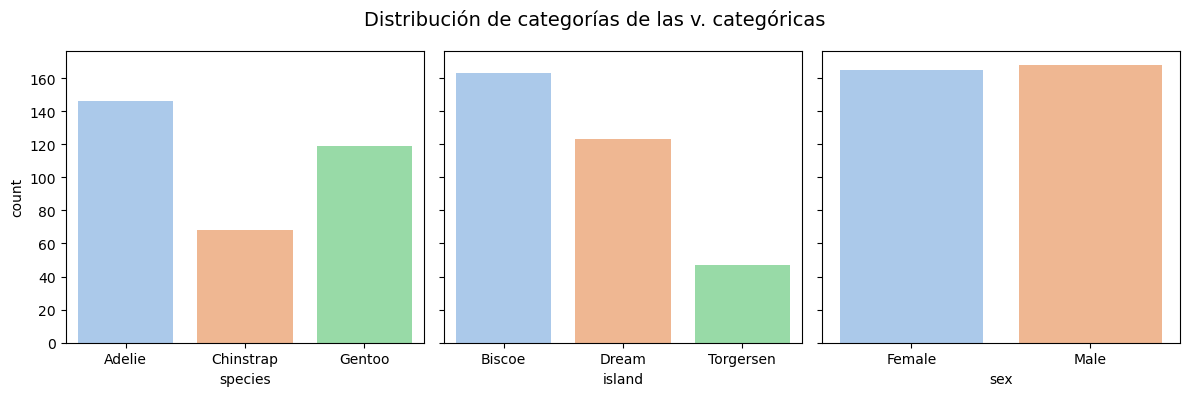

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
axes = axes.flatten()  

for i, cat in enumerate(f_categoricas):
    sns.countplot(x=cat, data=penguins, hue=cat, palette='pastel', ax=axes[i])

plt.suptitle('Distribución de categorías de las v. categóricas', fontsize=14)
plt.tight_layout()
plt.show()

---
### Variables numéricas
---

In [10]:
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


#### Histogramas

In [11]:
colores_clase = {
    "Adelie": "#4C78A8",     # azul petróleo
    "Chinstrap": "#E45756",  # coral
    "Gentoo": "#72B7B2"      # turquesa
}

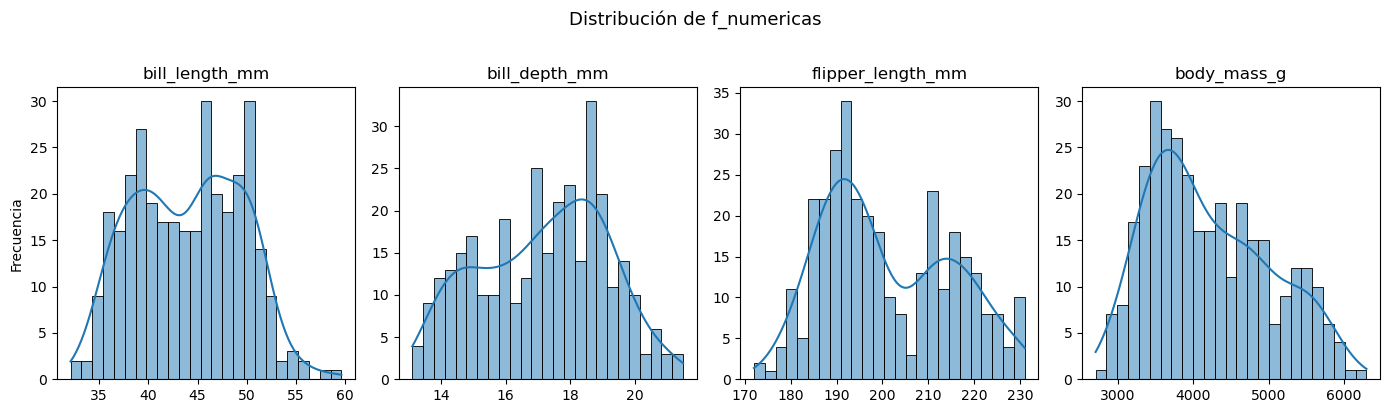

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for i, feat in enumerate(f_numericas):
    sns.histplot(
        data=penguins,
        x=feat,
        kde=True,
        alpha=0.5,
        bins=25,
        ax=axes[i],
        legend=(i == 0),
    )
    axes[i].set_title(feat)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frecuencia" if i % 4 == 0 else "")

plt.suptitle("Distribución de f_numericas", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

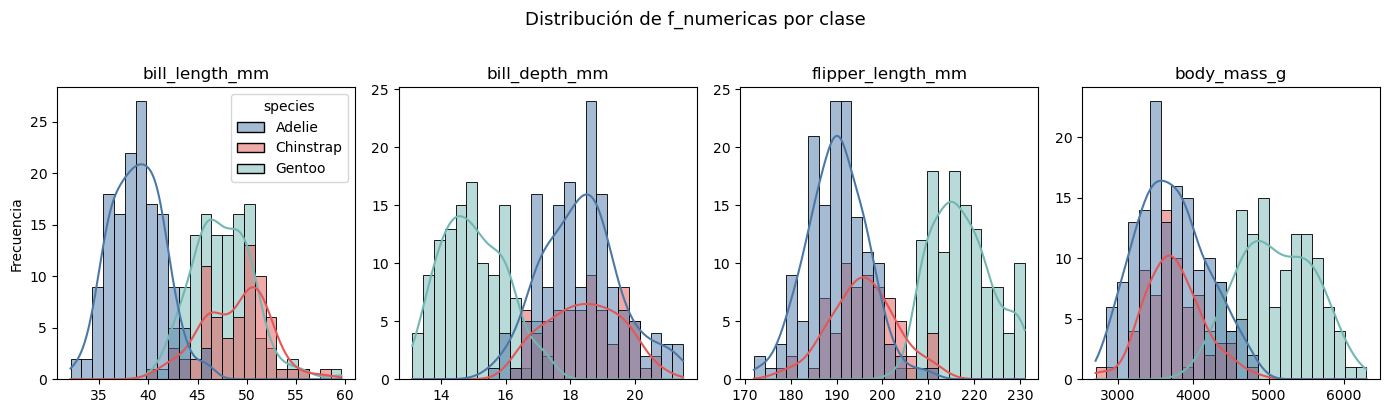

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for i, feat in enumerate(f_numericas):
    sns.histplot(
        data=penguins,
        x=feat,
        hue="species",
        palette=colores_clase,
        kde=True,
        alpha=0.5,
        bins=25,
        ax=axes[i],
        legend=(i == 0),
    )
    axes[i].set_title(feat)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frecuencia" if i % 4 == 0 else "")
    
plt.suptitle("Distribución de f_numericas por clase", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

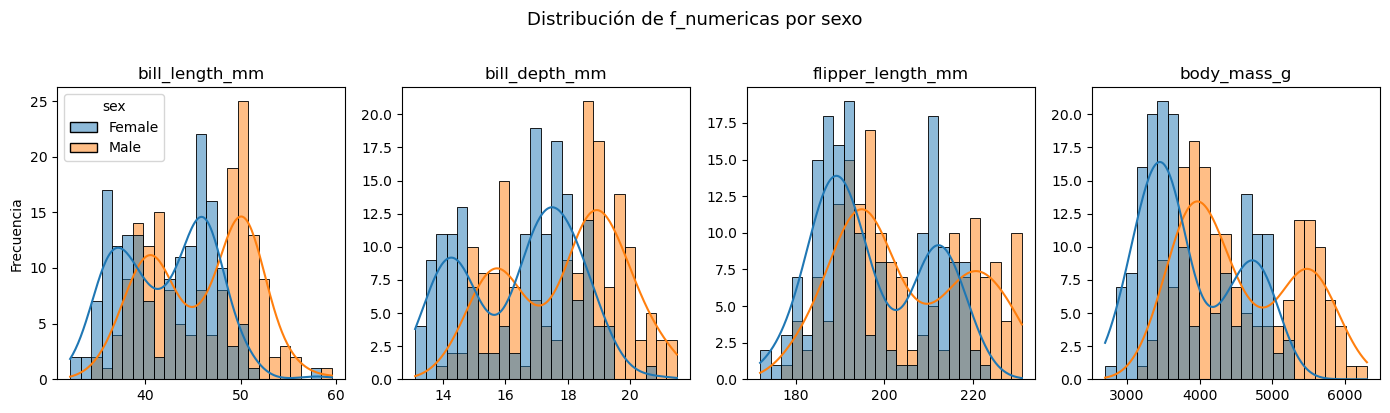

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for i, feat in enumerate(f_numericas):
    sns.histplot(
        data=penguins,
        x=feat,
        hue="sex",
        kde=True,
        alpha=0.5,
        bins=25,
        ax=axes[i],
        legend=(i == 0),
    )
    axes[i].set_title(feat)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frecuencia" if i % 4 == 0 else "")
    
plt.suptitle("Distribución de f_numericas por sexo", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

#### Boxplots

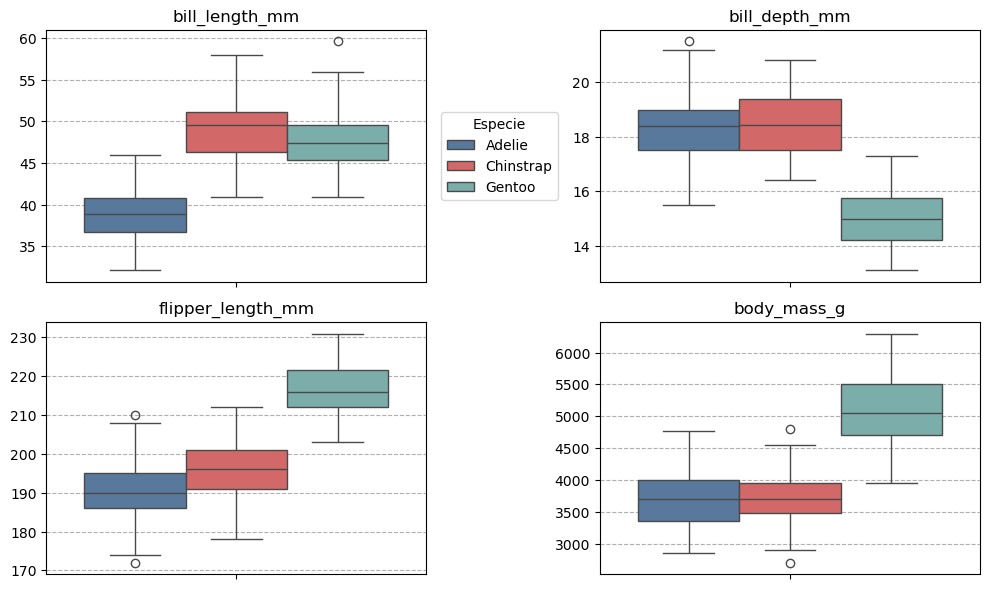

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.ravel()

for i, feat in enumerate(f_numericas):
    sns.boxplot(
        data=penguins,
        y=feat,
        hue='species',
        ax=axes[i],
        palette=colores_clase
    )

    axes[i].set_title(feat)
    axes[i].grid(axis='y', ls='--')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

    # Solo una leyenda
    if i == 0:
        axes[i].legend(
            title='Especie',
            loc='center left',
            bbox_to_anchor=(1.02, 0.5)
        )
    else:
        axes[i].get_legend().remove()

plt.tight_layout()
plt.show()

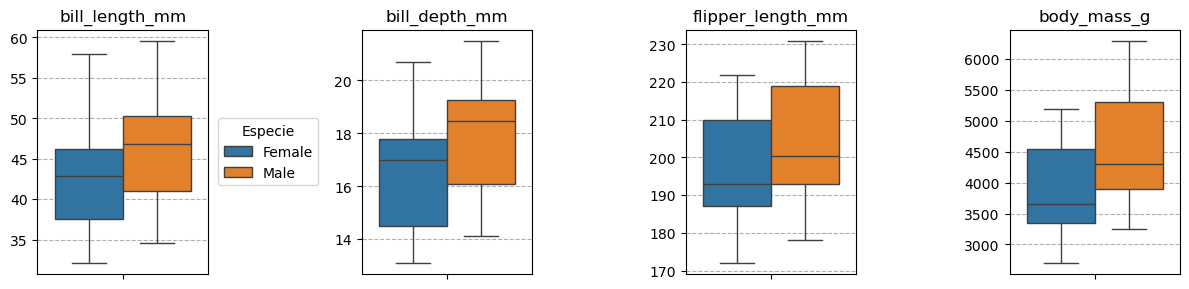

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes = axes.ravel()

for i, feat in enumerate(f_numericas):
    sns.boxplot(
        data=penguins,
        y=feat,
        hue='sex',
        ax=axes[i]
    )

    axes[i].set_title(feat)
    axes[i].grid(axis='y', ls='--')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

    # Solo una leyenda
    if i == 0:
        axes[i].legend(
            title='Especie',
            loc='center left',
            bbox_to_anchor=(1.02, 0.5)
        )
    else:
        axes[i].get_legend().remove()

plt.tight_layout()
plt.show()

---
### Visualizaciones entre pares de variables
---

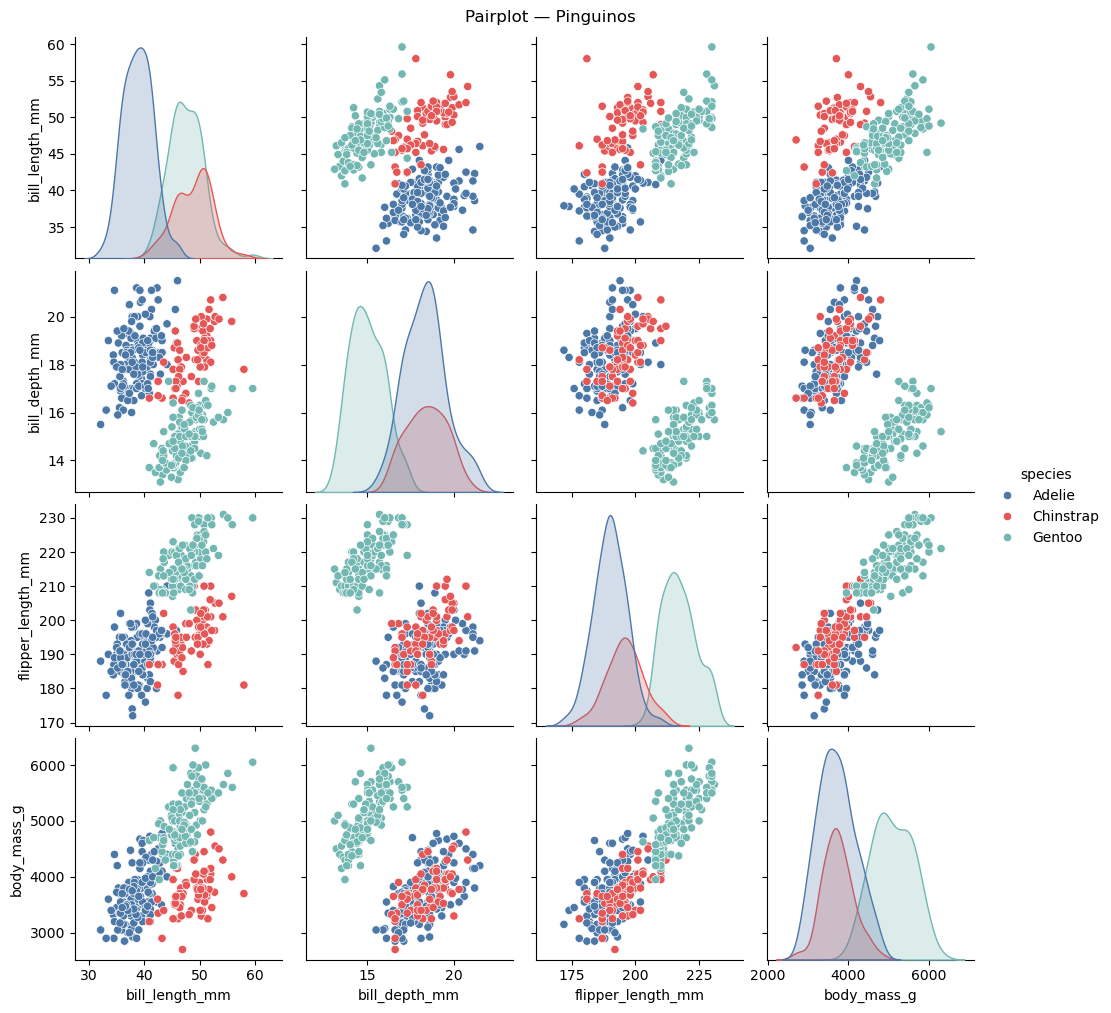

In [17]:
g = sns.pairplot(
    penguins,
    vars=f_numericas,
    hue='species',
    palette=colores_clase,
    diag_kind='kde'
)
g.figure.suptitle("Pairplot — Pinguinos", y=1.01)

plt.show()

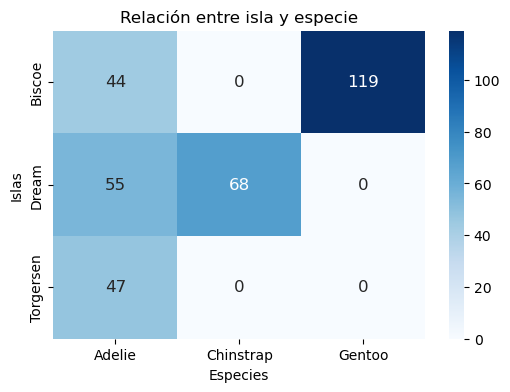

In [18]:
plt.figure(figsize=(6, 4))
sns.heatmap(pd.crosstab(penguins['island'], penguins['species']),
            annot=True, fmt='d', cmap='Blues', cbar=True, annot_kws={"size": 12})
plt.title('Relación entre isla y especie')
plt.xlabel('Especies')
plt.ylabel('Islas')
plt.show()

---
### Exploramos algunas asociaciones entre features
---

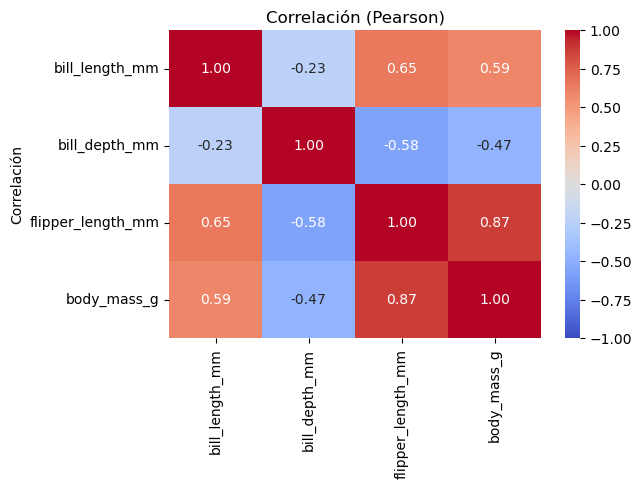

In [19]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    penguins[f_numericas].corr(), 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm",  
    center=0, 
    vmin=-1, 
    vmax=1)
plt.ylabel('Correlación')
plt.title("Correlación (Pearson)")
plt.show()

In [20]:
from scipy.stats import f_oneway

def eta_squared(continuous, categorical):
    mask       = continuous.notna() & categorical.notna()
    y, grp     = continuous[mask], categorical[mask]
    groups     = [g.values for _, g in y.groupby(grp, observed=True)]
    F, p       = f_oneway(*groups)
    grand_mean = y.mean()
    ss_total   = ((y - grand_mean) ** 2).sum()
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
    return ss_between / ss_total, p, F

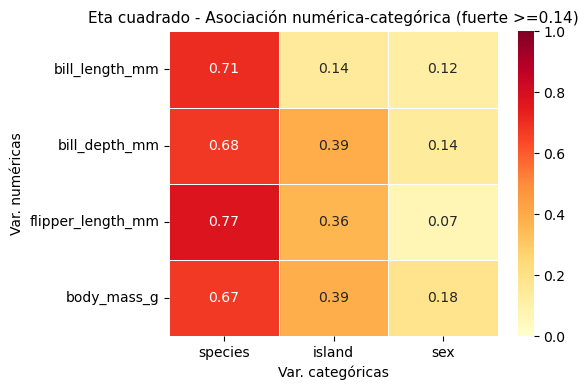

In [21]:
resultados = {}
for num_col in f_numericas:
    for cat_col in f_categoricas:
        eta2, p, F = eta_squared(penguins[num_col], penguins[cat_col])
        resultados[(num_col, cat_col)] = eta2

# Matriz de resultados
eta2_mat = pd.DataFrame(
    {cat: {num: resultados[(num, cat)] for num in f_numericas} for cat in f_categoricas}
)

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(eta2_mat, annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5, ax=ax)

ax.set_title("Eta cuadrado - Asociación numérica-categórica (fuerte >=0.14)", fontsize=11)
ax.set_xlabel("Var. categóricas")
ax.set_ylabel("Var. numéricas")
plt.tight_layout()
plt.show()

---
### Mutual information
para ver la relevancia predictiva de las features para predecir la especie.


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif

In [23]:
# split
X = penguins.copy()
X = X.drop(columns=["species"])
y = penguins['species'].cat.codes

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [24]:
# calculo mutual information

f_cat = ['island', 'sex']
X_mi = X_train.copy()

for col in f_cat:
    X_mi[col] = X_mi[col].cat.codes

discrete = X_mi.columns.isin(f_cat)

mi = mutual_info_classif(
    X_mi,
    y_train,
    discrete_features=discrete,
    random_state=42
)

In [25]:
mi_series = pd.Series(mi, index=X_mi.columns, name='MI').sort_values(ascending=False)
mi_result = pd.DataFrame({
    'score': mi_series
}).sort_values('score', ascending=False)

display(mi_result.style.format({'score': '{:.5f}'}))

,score
flipper_length_mm,0.60245
bill_depth_mm,0.57780
bill_length_mm,0.55769
body_mass_g,0.51812
island,0.50790
sex,0.00005
